In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
from torchvision import transforms, datasets
from matplotlib import pyplot as plt
from tqdm import tqdm
import sys, os
sys.path.append(os.path.abspath("../../lib"))
import util
import importlib
importlib.reload(util)

<module 'util' from 'C:\\Users\\amand\\Documents\\Research\\Project_LIDI\\VAE_Tutorials\\lib\\util.py'>

# Introduction
The vanilla VAE model was introduced in 2013 by Kingma et al in "Auto-encoding variational Bayes" and in 2014 by Rezende et al in "Stochastic backpropagation and approximate inference in deep generative models". Here, the standard VAE architecture is introduced and applied on MNIST.


### Motivating VAEs
VAEs ultimately solve a maximum likelihood problem by providing structure through latent variables. The model is then a function of the joint distribution $p(x,z)$ where $x$ is the data and $z$ is the latent. In maximum likelihood with latents, optimization depends on the posterior $p(z|x)$. When the posterior has a closed-form expression, methods such as the Expectation-Maximization (EM) algorithm (eventually) provide an exact estimate of the optimal parameters. 

Often, however, the posterior is intractable. In this case, EM can still be used with Monte Carlo estimates (e.g., via Gibbs or Metropolis-Hastings sampling), but it is very computationally expensive due to per-datapoint estimation and thus not scalable. An alternative is to approximate the true posterior $p(z|x)$ with a tractable, approximate form $q(z|x)$. With a decent approximation, $q(z|x)$ gets close enough to the true posterior, meaning true optimization of $\log p(x)$. To see this, consider the decomposition of the log likelihood (also see Bishop's machine learning book, EM chapter):
$$
\begin{align}
\log p(x) &= \log \frac{p(x,z)}{p(z|x)}
\\
&= \sum_z q(z|x) \log \left(\frac{p(x,z)}{p(z|x)} \frac{q(z|x)}{q(z|x)} \right)
\\
&= \sum_z q(z|x) \log \frac{p(x,z)}{q(z|x)} + \sum_z q(z|x) \log \frac{q(z|x)}{p(z|x)}
\\
&= \mathbb{E}_{q(z|x)} \left[ \log \frac{p(x,z)}{q(z|x)} \right] + KL(q(z|x) || p(z|x))
\end{align}
$$
where $KL$ is the KL divergence. Look at the last equation. The first term is the Evidence Lower BOund (ELBO) that is optimized in variational inference and VAEs. The second term is how far the approximate posterior diverges from the true posterior. Since the true posterior is intractable, it is infeasible to optimize over this term. Although it is dropped in variational inference, the KL term is always non-negative which makes the ELBO a lower bound for optimization.

The ELBO is further decomposed into the more standard expression of reconstruction loss and KL loss:
$$
\begin{align}
    ELBO &= \mathbb{E}_{q(z|x)} \left[ \log \frac{p(x,z)}{q(z|x)} \right]
    \\
    &= \underbrace{\mathbb{E}_{q(z|x)} \left[ \log p(x|z) \right]}_{\text{Reconstruction loss}} - \underbrace{KL(q(z|x) || p(z))}_{\text{KL loss}}.
\end{align}
$$

VAEs combine variational inference with neural networks to maximize the ELBO. When $q(z|x)$ is very expression, e.g. through a neural network, it comes very close to $p(z|x)$. VAEs achieve this through an encoder (inference) network that estimates parameters of $q(z|x)$, and a decoder (generative) network that estimates parameters of $p(x|z)$. The decoder network relies on Monte Carlo samples of $z\sim q(z|x)$. To allow backpropagation, $z$ is actually sampled through a standard normal distribution $\epsilon$. The reparameterization trick re-expresses $z = \mu_q + \sigma^2_q \epsilon$ so $(\mu_q, \sigma^2_q)$ of $q(z|x)$ can be learned through backprop. In many applications, the prior, inference, and generative models are all Gaussian distributed and it is the parameters of the Gaussians (and neural networks) that are learned. Note that it is also possible to define non-Gaussian distributions in that case that the data are discrete, for example.

# Setup

### Utility functions

In [2]:
# Log likelihood of multivariate normal with diagonal covariance
def normal_ll(x, mu, logvar):
    if torch.cuda.is_available():
        x = x.cuda()
        mu = mu.cuda()
        logvar = logvar.cuda()

    const = x.shape[-1] * torch.tensor(2*torch.pi).log()
    ll = -0.5 * (const + (logvar + (x - mu).pow(2) / logvar.exp()).sum(-1))
    return ll

In [3]:
# KL divergence between two multivariate Gaussians: KL(N(mu0, var0) || N(mu1, var1))
def kl_normal(mu0, log_var0, mu1, log_var1):
    dim = mu0.shape[1]
    trace = log_var0.exp() / log_var1.exp()
    quad = (mu0 - mu1).pow(2) / log_var1.exp()
    logdet = log_var1 - log_var0
    kl_div = (trace + quad + logdet).sum(-1) - dim
    return 0.5*kl_div

In [4]:
# Monte Carlo samples for reparameterization trick
def sample(mu, log_var):
    z = mu + (0.5 * log_var).exp() * torch.randn_like(mu)
    return z

### MLP network

In [5]:
class MLP(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()

        hidden = 256      # dimension of hidden layer
        num_layers = 2   # number of hidden layers

        hidden_dims = num_layers * [hidden]
        hidden_dims = [in_dim] + hidden_dims

        # Define middle layers
        layer_lst = []
        for n in range(num_layers):
            layer_lst.append(nn.Linear(hidden_dims[n], hidden_dims[n + 1]))
            layer_lst.append(nn.LeakyReLU(0.01))
        self.layers = nn.Sequential(*layer_lst)

        # Define output layers
        self.mu = nn.Linear(hidden_dims[-1], out_dim)
        self.log_var = nn.Linear(hidden_dims[-1], out_dim)

    def forward(self, x):
        out = self.layers(x)
        return self.mu(out), self.log_var(out)

### VAE model

In [6]:
class VAE(nn.Module):
    def __init__(self, kx):
        super().__init__()
        
        pz = 4  # latent dimension

        self.encoder = MLP(kx, pz)
        self.decoder = MLP(pz, kx)

    def forward(self, x):
        self.mu_e, self.logvar_e = self.encoder(x)
        self.z = sample(self.mu_e, self.logvar_e)
        self.mu_d, self.logvar_d = self.decoder(self.z)

        return self.mu_e, self.logvar_e

    def loss(self, x):
        recon = -1 * normal_ll(x, self.mu_d, self.logvar_d)
        kl_div = kl_normal(self.mu_e, self.logvar_e, torch.zeros_like(self.mu_e), torch.ones_like(self.logvar_e))

        return recon.mean(), kl_div.mean()

    def get_z_samples(self):
        return self.z.cpu().detach()

### Prepare for training

In [7]:
# Load CPU or GPU
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA")
else:
    device = torch.device("cpu")
    print("Using CPU")

Using CPU


In [8]:
# General training settings
cfg = {
    'rng': 1,
    'batch_size': 256,
    'epochs': 5,
    'lr': 0.0001
}

# Set random seed
torch.manual_seed(cfg['rng'])
np.random.seed(cfg['rng'])

# Training

### Prepare data

In [9]:
# Load dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view(-1))])
data = datasets.MNIST(root="../../data", download=True, transform=transform)
kx = 784

# Split into train, validation, test sets with random shuffle
generator = torch.Generator().manual_seed(cfg['rng'])
train_data, valid_data, test_data = random_split(data, [0.8, 0.1, 0.1], generator=generator)
train_loader = DataLoader(train_data, cfg['batch_size'], shuffle=True)
test_loader = DataLoader(test_data, batch_size=len(test_data))

In [10]:
recon_arr = []
kl_arr = []
ami_arr = []

### Define model

In [11]:
model = VAE(kx).to(device)
optimizer = torch.optim.Adam(params=model.parameters(), lr=cfg['lr'])
n_parameters = sum(param.numel() for param in model.parameters())
print("Number of parameters: " + str(n_parameters))

Number of parameters: 738856


### Main training loop

In [12]:
for epoch in tqdm(range(cfg['epochs'])):
    for batch in train_loader:
        # Get batch data on device
        x, u = batch[0].to(device), batch[1].to(device)
        u = u.to(torch.float32)

        # Forward pass
        mu_q, logvar_q = model(x)

        # Calculate mutual information
        zs = model.get_z_samples()
        ami = util.approximate_mi(mu_q, logvar_q, zs)
        ami_arr.append(ami)

        # Update model, compute loss
        optimizer.zero_grad()
        losses = model.loss(x)
        loss = losses[0] + losses[1]
        loss.backward()
        optimizer.step()

        # Save losses
        recon_arr.append(losses[0].item())
        kl_arr.append(losses[1].item())

100%|██████████| 5/5 [01:36<00:00, 19.31s/it]


# Evaluation

### Plot training loss

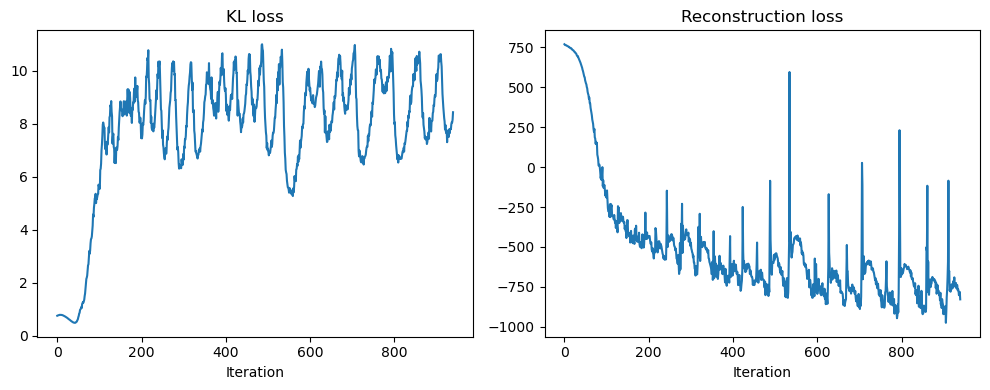

In [13]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

# KL loss
axs[0].plot(kl_arr)
axs[0].set_xlabel("Iteration")
axs[0].set_title("KL loss")
# Reconstruction loss
axs[1].plot(recon_arr)
axs[1].set_xlabel("Iteration")
axs[1].set_title("Reconstruction loss")
plt.tight_layout()

### Plot mutual information I(X;Z)

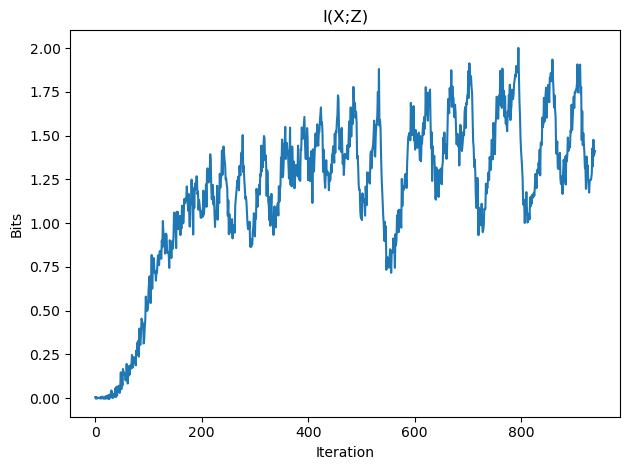

In [14]:
plt.plot(ami_arr)
plt.xlabel("Iteration")
plt.title("I(X;Z)")
plt.ylabel("Bits")
plt.tight_layout()

### Evaluation on test data

In [15]:
model.eval()
with torch.no_grad():
    for batch in test_loader:
        x, u = util.get_batch(batch, 'MNIST', device)
        output = model(x)

### Plot 2d PCA representation

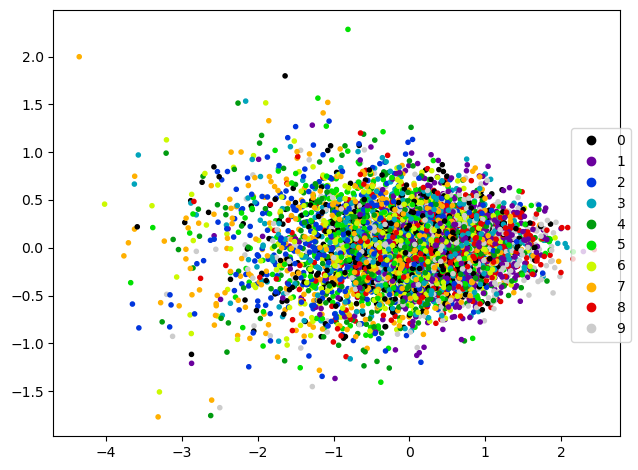

In [16]:
zs = model.get_z_samples()
u = u.detach().cpu()
util.plot_multiple_pca([zs], lbls=u)